In [1]:
# ===== Imports ====
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import pandas as pd

df = pd.read_csv("bone_tumor_dataset_570.csv")

print("Dataset Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Dataset Shape: (570, 13)
Columns: Index(['patient_id', 'age', 'tumor_size_mm', 'bone_density',
       'bone_texture_score', 'cell_irregularity', 'calcification_level',
       'tumor_growth_rate', 'pain_score', 'inflammation_index',
       'metastasis_risk', 'biomarker_level', 'diagnosis'],
      dtype='str')


,patient_id,age,tumor_size_mm,bone_density,bone_texture_score,cell_irregularity,calcification_level,tumor_growth_rate,pain_score,inflammation_index,metastasis_risk,biomarker_level,diagnosis
0,1,69,43.39,1.512,1.151,6.35,3.31,1.078,2,6.90,0.828,413.91,Malignant
1,2,32,33.46,1.895,0.709,0.49,4.83,0.511,1,9.62,0.740,152.80,Benign
2,3,78,132.10,2.195,1.123,10.44,0.28,1.290,2,7.33,0.789,72.43,Benign
3,4,38,114.28,0.484,0.711,0.87,4.85,1.843,4,4.95,0.119,49.65,Benign
4,5,41,9.89,2.548,0.601,11.47,1.07,1.097,9,6.34,0.141,416.92,Benign


In [ ]:
# ===== Data Cleaning =====

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Drop any missing rows 
df = df.dropna()

# Encode diagnosis (Benign=0, Malignant=1)
df['diagnosis'] = df['diagnosis'].map({'Benign': 0, 'Malignant': 1})

# Final check
print("\nUnique Diagnosis Values:", df['diagnosis'].unique())

Missing Values:
 patient_id             0
age                    0
tumor_size_mm          0
bone_density           0
bone_texture_score     0
cell_irregularity      0
calcification_level    0
tumor_growth_rate      0
pain_score             0
inflammation_index     0
metastasis_risk        0
biomarker_level        0
diagnosis              0
dtype: int64

Unique Diagnosis Values: [1 0]


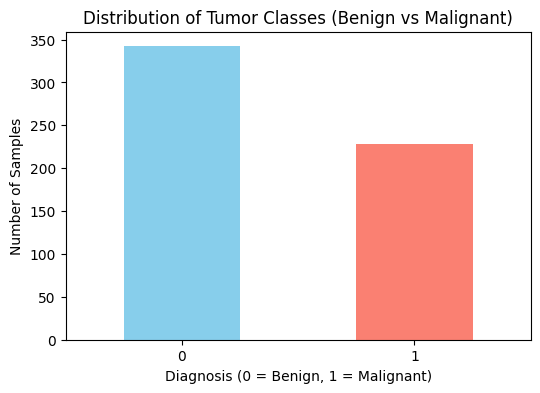

In [4]:
# ===== Dataset Distribution Graph  =====
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['diagnosis'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'salmon']
)
plt.title("Distribution of Tumor Classes (Benign vs Malignant)")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

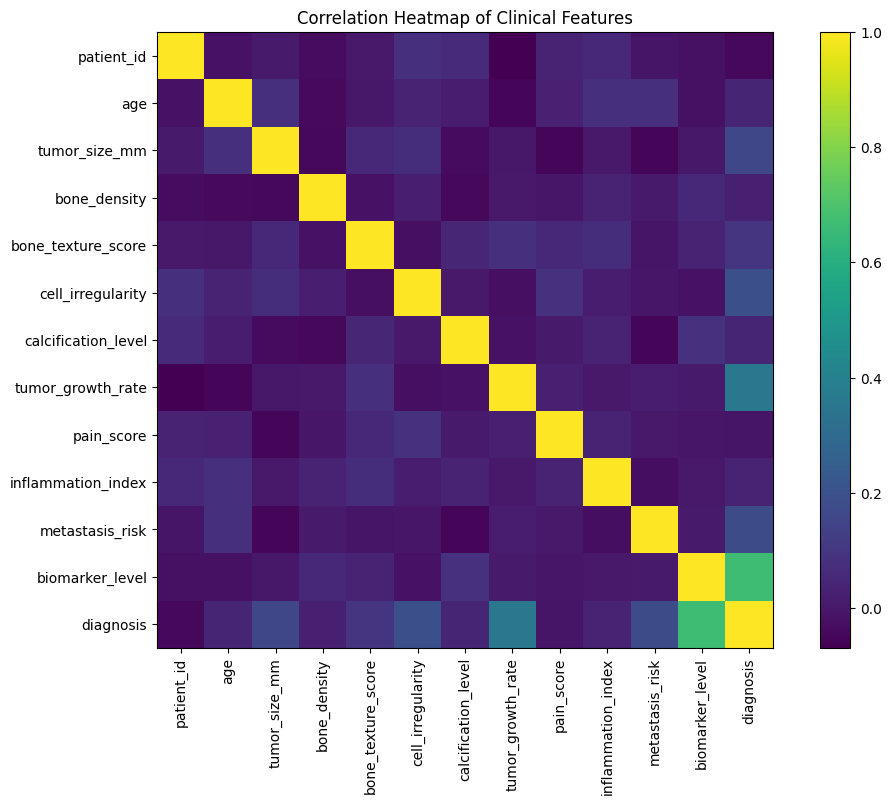

In [5]:
# ===== Correlation Heatmap =====
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
plt.imshow(corr)
plt.title("Correlation Heatmap of Clinical Features")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [6]:
# ===== Feature & Target Split =====

# Drop non-useful column (patient_id should NOT be used)
X = df.drop(columns=['diagnosis', 'patient_id'], errors='ignore')
y = df['diagnosis']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (570, 11)
y Shape: (570,)


In [7]:
# ===== Train Test Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ===== Feature Scaling =====
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (456, 11)
Testing Shape: (114, 11)


In [8]:
# ===== Results Table =====
results = pd.DataFrame(columns=['Algorithm', 'Accuracy'])

In [9]:
# ===== Logistic Regression =====
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)
print(classification_report(y_test, y_pred_lr))

results = pd.concat([
    results,
    pd.DataFrame([{'Algorithm': 'Logistic Regression', 'Accuracy': lr_acc}])
], ignore_index=True)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        68
           1       1.00      0.96      0.98        46

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[68  0]
 [ 2 44]]


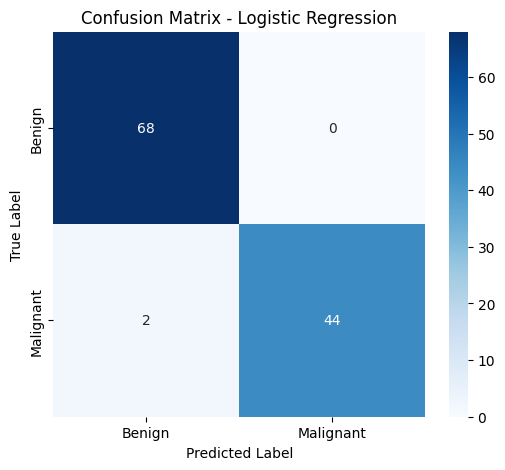

In [10]:
# ===== Confusion Matrix Visualization  =====
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

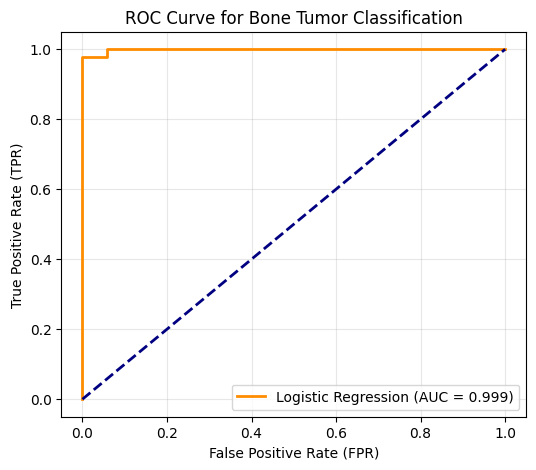

AUC Score: 0.9987212276214834


In [11]:
# ===== Fig: ROC Curve  =====
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use Logistic Regression
y_prob = lr.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='Logistic Regression (AUC = %0.3f)' % roc_auc)

# Random baseline line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Bone Tumor Classification')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("AUC Score:", roc_auc)

In [12]:
# ===== Decision Tree =====
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

results = pd.concat([
    results,
    pd.DataFrame([{'Algorithm': 'Decision Tree', 'Accuracy': dt_acc}])
], ignore_index=True)

Decision Tree Accuracy: 0.9210526315789473


In [13]:
# ===== Random Forest =====
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

results = pd.concat([
    results,
    pd.DataFrame([{'Algorithm': 'Random Forest', 'Accuracy': rf_acc}])
], ignore_index=True)

Random Forest Accuracy: 0.9210526315789473


In [14]:
# ===== SVM =====
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)

results = pd.concat([
    results,
    pd.DataFrame([{'Algorithm': 'SVM', 'Accuracy': svm_acc}])
], ignore_index=True)

SVM Accuracy: 0.9649122807017544


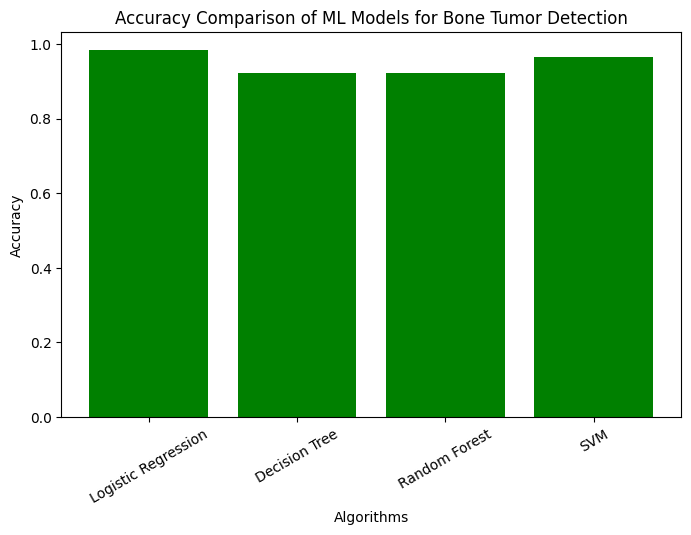

In [15]:
# ===== Accuracy Comparison Graph (Final Result Figure) =====
plt.figure(figsize=(8,5))
plt.bar(results['Algorithm'], results['Accuracy'], color='green')
plt.title("Accuracy Comparison of ML Models for Bone Tumor Detection")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [16]:
# ===== Save Best Model to Disk ) =====
import joblib

# pick best model by accuracy
best_idx = results['Accuracy'].idxmax()
best_algo = results.loc[best_idx, 'Algorithm']
print("Best algorithm:", best_algo)

# correct model mapping 
model_map = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'SVM': svm
}

# get best model
best_model = model_map[best_algo]

# save model
joblib.dump(best_model, 'best_bone_tumor_model.joblib')
print("Saved best model as best_bone_tumor_model.joblib")

Best algorithm: Logistic Regression
Saved best model as best_bone_tumor_model.joblib
